In [21]:
from langgraph.graph import StateGraph,END
from langchain_openai import ChatOpenAI
from langchain.tools import tool 
from typing import TypedDict

# define State

In [12]:
class AgentState(TypedDict):
    input: str
    output: str

# create Tool

In [13]:
import re
@tool
def calculate(expression: str) -> str:
    """ Evaluate mathematical expression """

    try:
        # extract only math part
        cleaned = re.sub(r"[^0-9+\-*(). ]","",expression)

        return str(evel(cleaned))
    except Exception as e:
        return f"error: {e}"

# LLM setup

In [14]:
from langchain_ollama import ChatOllama

In [15]:
llm = ChatOllama(
    model= 'llama3.1:8b',
    temperature=2
)


# step 5 LLM Node (Reasoning)

In [16]:
def reaspm_node(state: AgentState):
    response = llm.invoke(state["input"])
    return {"output":response.content}

# step 6 Tool node (Action)

In [17]:
def tool_node(state: AgentState):
    result = calculate.invoke(state["input"])
    return {"output":result}

# step 7 conditional routing 

In [18]:
def should_use_tool(state: AgentState):
    if any(char.isdigit() for char in state["input"]):
        return "tool"
    return "end"

# step 8 build the graph 

In [32]:
builder = StateGraph(AgentState)

builder.add_node("reason", reaspm_node)
builder.add_node("tool", tool_node)

builder.set_entry_point("reason")

# --- reason node conditional edges ---
builder.add_conditional_edges(
    "reason",
    should_use_tool,
    {
        "tool": "tool",
        "end": END
    }
)

graph = builder.compile()

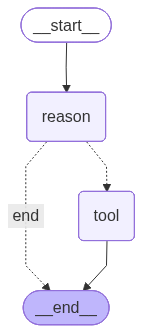

In [33]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

# run Agent 

In [34]:
result = graph.invoke({"input":"what is 25 * 4 + 10 "})
print(result)

{'input': 'what is 25 * 4 + 10 ', 'output': "error: name 'evel' is not defined"}
